In [61]:
import json
import os
import csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
REPO_ROOT = Path.cwd().resolve().parent
PROCESSED_ROOT = REPO_ROOT / "data" / "processed" / "peer"

In [179]:
# import datasets as dataframes for each of the 2 tasks
def load_datasets(task="localization", split="train"):
    with open(f'{PROCESSED_ROOT}/{task}/{split}.csv', 'r') as f:
        data = pd.read_csv(f)
    return data.drop(columns=["idx", "dataset", "split"])

localization_dfs = {
    "train": load_datasets(task="localization", split="train"),
    "test": load_datasets(task="localization", split="test"),
    "valid": load_datasets(task="localization", split="valid"),
}

solubility_dfs = {
    "train": load_datasets(task="solubility", split="train"),
    "test": load_datasets(task="solubility", split="test"),
    "valid": load_datasets(task="solubility", split="valid"),
}

combined_localization_df = pd.concat([df.assign(split=split_name) for split_name, df in localization_dfs.items()],ignore_index=True)
combined_solubility_df = pd.concat([df.assign(split=split_name) for split_name, df in solubility_dfs.items()],ignore_index=True)

In [64]:
localization_dfs['train'].head()

,sequence,label
0,MEFRGSGATAVEQHLLQSETPGKNGLQATSSDQVGRTLRWFTTVVL...,0
1,MKNSTAASSRWTKSRLSHFFPSYTNSSGMGAASTDQSSTQGEELHH...,0
2,MKMASSLAFLLLNFHVSLLLVQLLTPCSAQFSVLGPSGPILAMVGE...,0
3,MDHSAEKAAANAEVPQELLEEMLWYFRAEDAAPWNYSILVLAVLVV...,0
4,MIPCRAVLTFARCLIRRKIVTLDSLEDSKLCRCLTTVDLIALGVGS...,0


Start by looking at label distributions

In [65]:
localization_dfs['train']["label"].value_counts()

label
6    2426
1    1635
9    1185
5     906
0     800
2     516
8     453
3     214
4     192
7      93
Name: count, dtype: int64

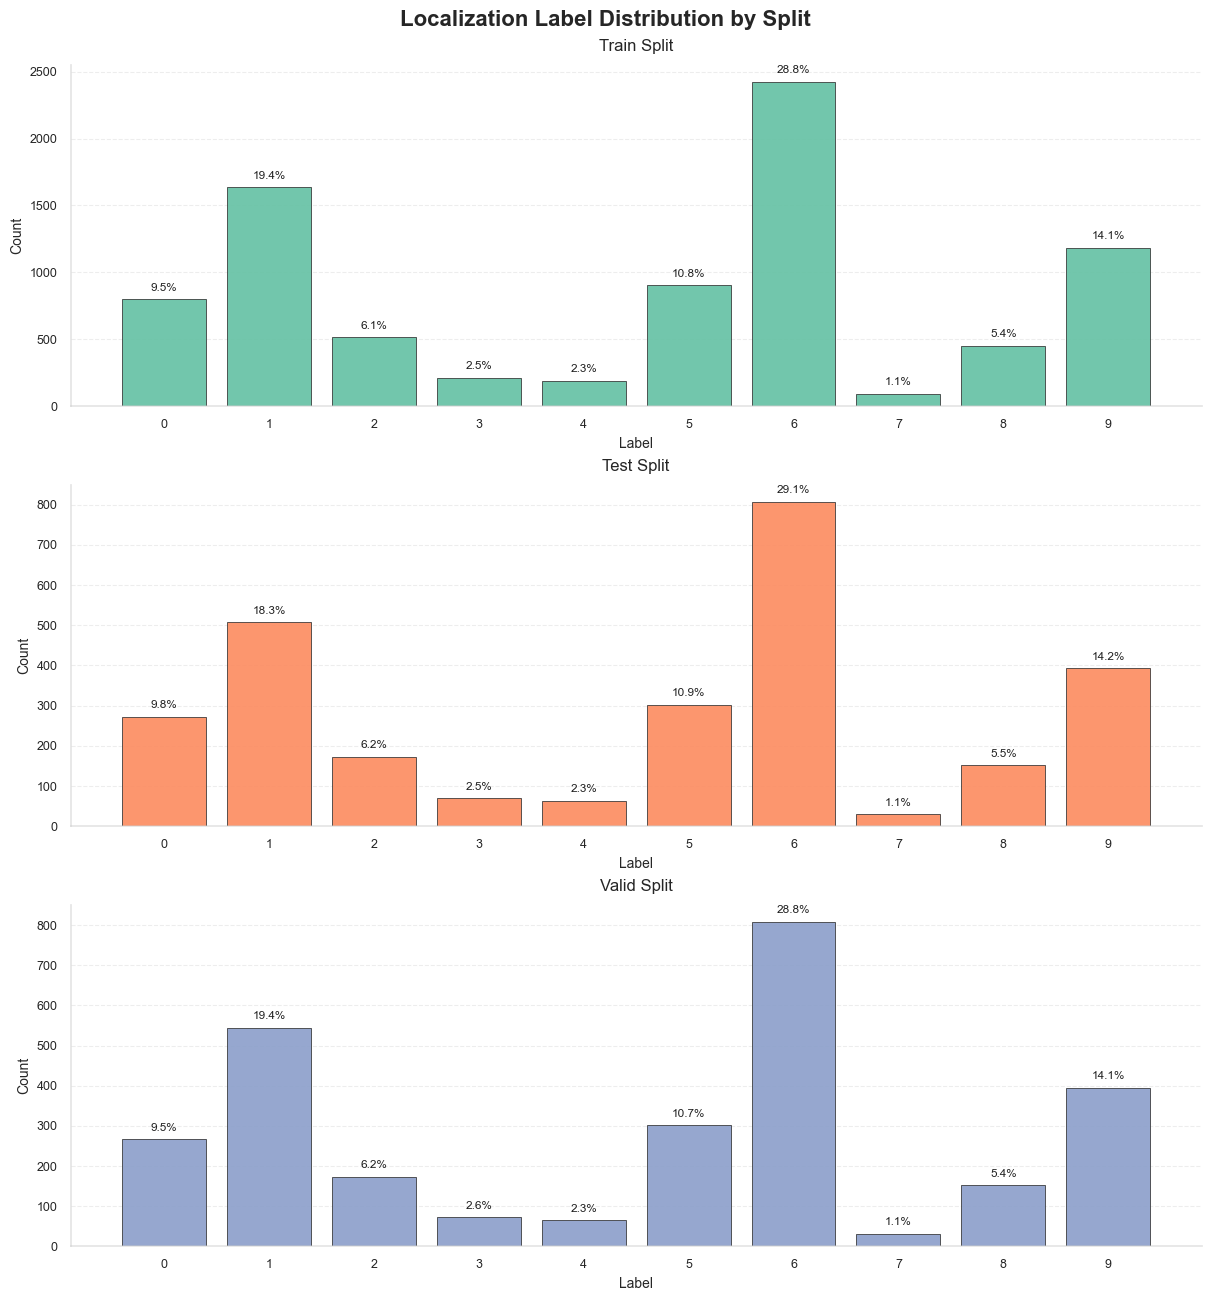


Localization imbalance diagnostics
- train: majority=6 (2426, 28.8%), minority=7 (93), max/min ratio=26.09
- test: majority=6 (808, 29.1%), minority=7 (30), max/min ratio=26.93
- valid: majority=6 (809, 28.8%), minority=7 (31), max/min ratio=26.10


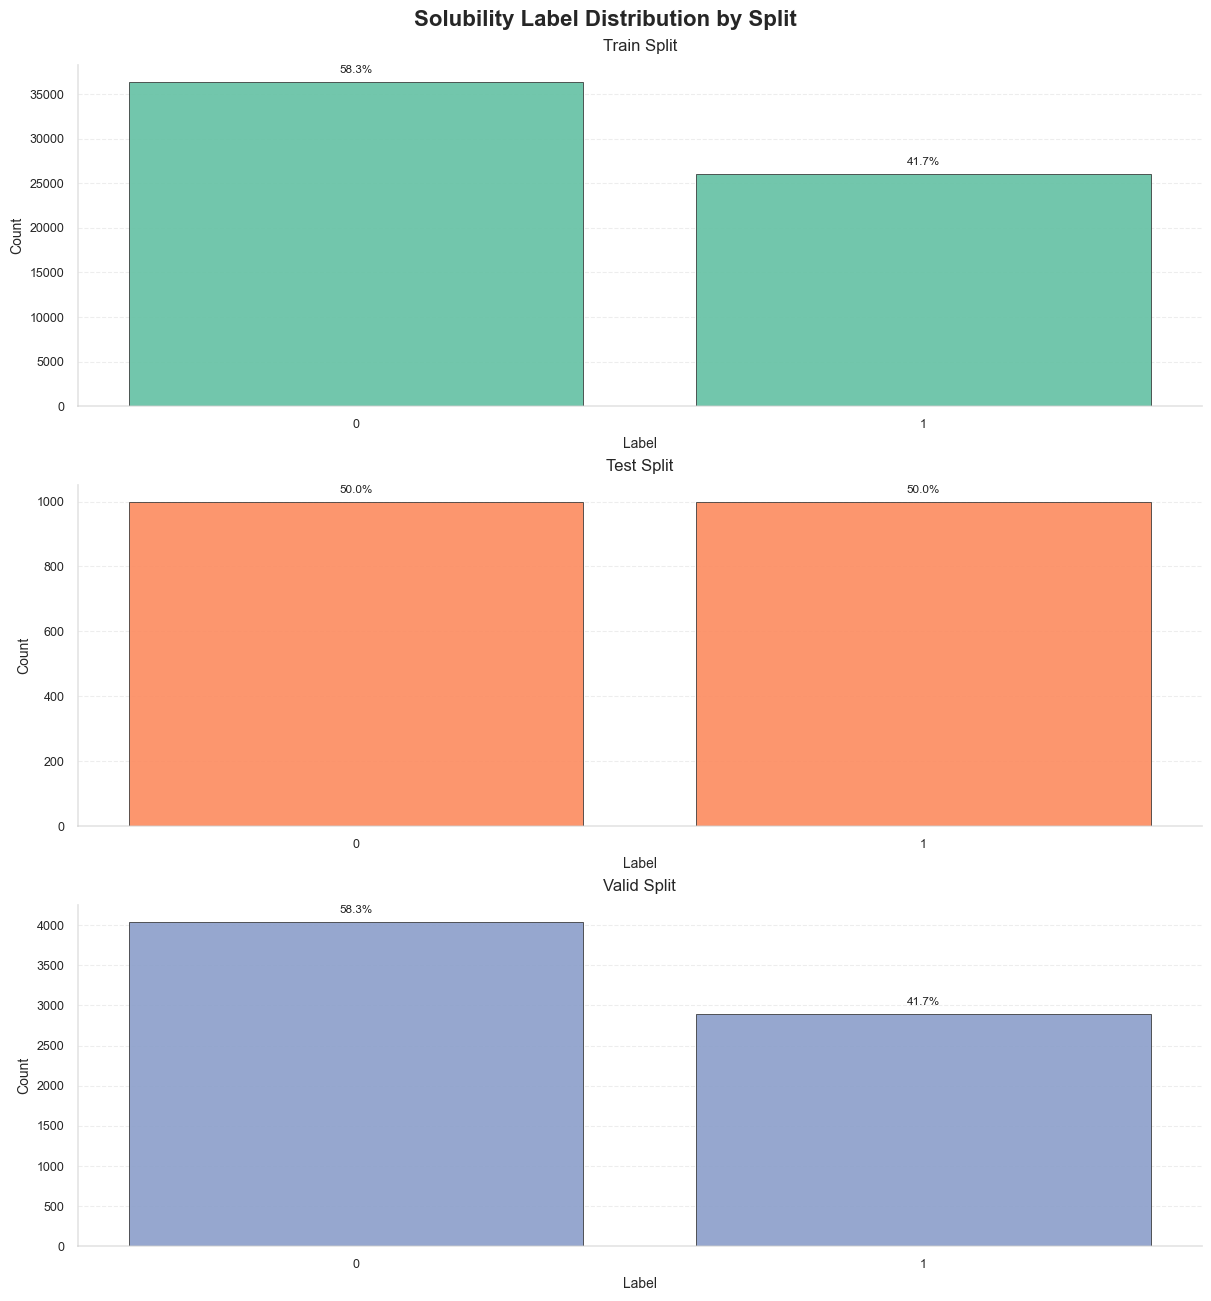


Solubility imbalance diagnostics
- train: majority=0 (36403, 58.3%), minority=1 (26075), max/min ratio=1.40
- test: majority=1 (1000, 50.0%), minority=0 (999), max/min ratio=1.00
- valid: majority=0 (4045, 58.3%), minority=1 (2897), max/min ratio=1.40


In [66]:
def plot_label_distribution(task_name, dfs_by_split):
    sns.set_theme(style="whitegrid", context="notebook")

    splits = list(dfs_by_split.keys())
    n_splits = len(splits)

    # One subplot per split so each split has its own label distribution chart
    fig, axes = plt.subplots(
        n_splits,
        1,
        figsize=(12, 4.2 * n_splits),
        sharex=False,
        constrained_layout=True,
    )
    if n_splits == 1:
        axes = [axes]

    fig.suptitle(
        f"{task_name.title()} Label Distribution by Split",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )

    count_by_split = {}
    split_colors = dict(zip(splits, sns.color_palette("Set2", n_colors=n_splits)))

    for ax, split in zip(axes, splits):
        split_counts = dfs_by_split[split]["label"].value_counts(dropna=False).sort_index()
        count_by_split[split] = split_counts

        labels = split_counts.index.astype(str)
        counts = split_counts.values
        pct = (split_counts / split_counts.sum()) * 100

        bars = ax.bar(
            labels,
            counts,
            color=split_colors[split],
            edgecolor="#2f2f2f",
            linewidth=0.6,
            alpha=0.92,
        )

        ax.set_title(f"{split.title()} Split", fontsize=12, pad=10)
        ax.set_xlabel("Label", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
        ax.grid(axis="x", visible=False)
        ax.tick_params(axis="x", rotation=0, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

        max_count = max(counts) if len(counts) > 0 else 0
        offset = max(1, int(max_count * 0.02))

        # Annotate bars with percentage for fast imbalance inspection
        for bar, c, p in zip(bars, counts, pct.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                c + offset,
                f"{p:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8.5,
                color="#1f1f1f",
            )

    plt.show()

    # Quick imbalance diagnostics
    print(f"\n{task_name.title()} imbalance diagnostics")
    for split, split_counts in count_by_split.items():
        nonzero = split_counts[split_counts > 0]
        if len(nonzero) == 0:
            print(f"- {split}: no labels found")
            continue

        majority = nonzero.max()
        minority = nonzero.min()
        majority_label = nonzero.idxmax()
        minority_label = nonzero.idxmin()
        ratio = majority / minority if minority > 0 else float("inf")
        majority_pct = (majority / nonzero.sum()) * 100

        print(
            f"- {split}: majority={majority_label} ({majority}, {majority_pct:.1f}%), "
            f"minority={minority_label} ({minority}), max/min ratio={ratio:.2f}"
        )

# Run for both tasks
plot_label_distribution("localization", localization_dfs)
plot_label_distribution("solubility", solubility_dfs)

Plots above show a pretty significant class imbalance for localization, but not terrible for solubility.

Localization:
- Seems to be stratefied, meaning that the proportions of each label are identical across all splits
- Class 6 has the most by far
- Class 7 is the smallest by far

Solubility:
- Proportions are not as close across all splits
- Class 0 has a slight edge in percentage for train and val split
- For test set, it seems to be about 50/50

Next plot, let's look to see if there is any data leakage within any of splits

In [ ]:
# TODO: DATA LEAKAGE TEST
import pandas as pd
from itertools import combinations

def check_data_leakage(
    df: pd.DataFrame,
    sequence_col: str = "sequence",
    label_col: str = "label",
    split_col: str = "split",
) -> dict:
    """
    Check for exact sequence leakage across train/val/test splits.

    Detects:
    1. Exact duplicate sequences across different splits
    2. Same sequence appearing with different labels
    3. Duplicate sequences within each split

    Returns a dictionary of summary tables.
    """

    required_cols = {sequence_col, label_col, split_col}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    results = {}

    # Normalize sequences just in case
    work_df = df.copy()
    work_df[sequence_col] = work_df[sequence_col].astype(str).str.upper().str.strip()

    # 1. Duplicate sequences within each split
    within_split_duplicates = (
        work_df
        .groupby([split_col, sequence_col])
        .size()
        .reset_index(name="count")
        .query("count > 1")
        .sort_values(["count"], ascending=False)
    )

    results["within_split_duplicates"] = within_split_duplicates

    # 2. Same sequence appearing in multiple splits
    seq_split_counts = (
        work_df
        .groupby(sequence_col)[split_col]
        .nunique()
        .reset_index(name="num_splits")
    )

    leaked_sequences = seq_split_counts.query("num_splits > 1")[sequence_col]

    cross_split_leakage = (
        work_df[work_df[sequence_col].isin(leaked_sequences)]
        .sort_values([sequence_col, split_col])
    )

    results["cross_split_leakage"] = cross_split_leakage

    # 3. Same sequence with multiple labels
    seq_label_counts = (
        work_df
        .groupby(sequence_col)[label_col]
        .nunique()
        .reset_index(name="num_labels")
    )

    conflicting_sequences = seq_label_counts.query("num_labels > 1")[sequence_col]

    label_conflicts = (
        work_df[work_df[sequence_col].isin(conflicting_sequences)]
        .sort_values([sequence_col, label_col])
    )

    results["label_conflicts"] = label_conflicts

    # 4. Pairwise split overlap counts
    overlap_rows = []

    split_names = sorted(work_df[split_col].unique())

    split_to_sequences = {
        split: set(work_df.loc[work_df[split_col] == split, sequence_col])
        for split in split_names
    }

    for split_a, split_b in combinations(split_names, 2):
        overlap = split_to_sequences[split_a] & split_to_sequences[split_b]

        overlap_rows.append({
            "split_a": split_a,
            "split_b": split_b,
            "num_overlapping_sequences": len(overlap)
        })

    results["pairwise_split_overlap"] = pd.DataFrame(overlap_rows)

    # 5. Summary
    results["summary"] = pd.DataFrame([{
        "num_sequences": len(work_df),
        "num_unique_sequences": work_df[sequence_col].nunique(),
        "num_within_split_duplicate_rows": len(within_split_duplicates),
        "num_cross_split_leakage_rows": len(cross_split_leakage),
        "num_unique_leaked_sequences": len(leaked_sequences),
        "num_label_conflict_rows": len(label_conflicts),
        "num_unique_label_conflict_sequences": len(conflicting_sequences),
    }])

    return results



solubility_leakage_results = check_data_leakage(combined_solubility_df)
localization_leakage_results = check_data_leakage(combined_localization_df)

for name, results in {"solubility": solubility_leakage_results,"localization": localization_leakage_results,}.items():
    print(f"\n{name.upper()} SUMMARY")
    print(results["summary"])
    print(f"\n{name.upper()} PAIRWISE SPLIT OVERLAP")
    print(results["pairwise_split_overlap"])
    print(f"\n{name.upper()} LABEL CONFLICTS")
    print(results["label_conflicts"].head())
    
    


SOLUBILITY SUMMARY
   num_sequences  num_unique_sequences  num_within_split_duplicate_rows  \
0          71419                 71419                                0   

   num_cross_split_leakage_rows  num_unique_leaked_sequences  \
0                             0                            0   

   num_label_conflict_rows  num_unique_label_conflict_sequences  
0                        0                                    0  

SOLUBILITY PAIRWISE SPLIT OVERLAP
  split_a split_b  num_overlapping_sequences
0    test   train                          0
1    test   valid                          0
2   train   valid                          0

SOLUBILITY LABEL CONFLICTS
Empty DataFrame
Columns: [sequence, label, split]
Index: []

LOCALIZATION SUMMARY
   num_sequences  num_unique_sequences  num_within_split_duplicate_rows  \
0          14004                 13949                               42   

   num_cross_split_leakage_rows  num_unique_leaked_sequences  \
0                           

No data leakage found between splits

## Biological Breakdown

Above is standard class imbalance, and stuff like that. Below we will start looking into the sequences from a more biological lense.

First, lets break down the amino acids by their chemical properties, we espcially will care about:
- charge
- polarity
- hydrophobicity



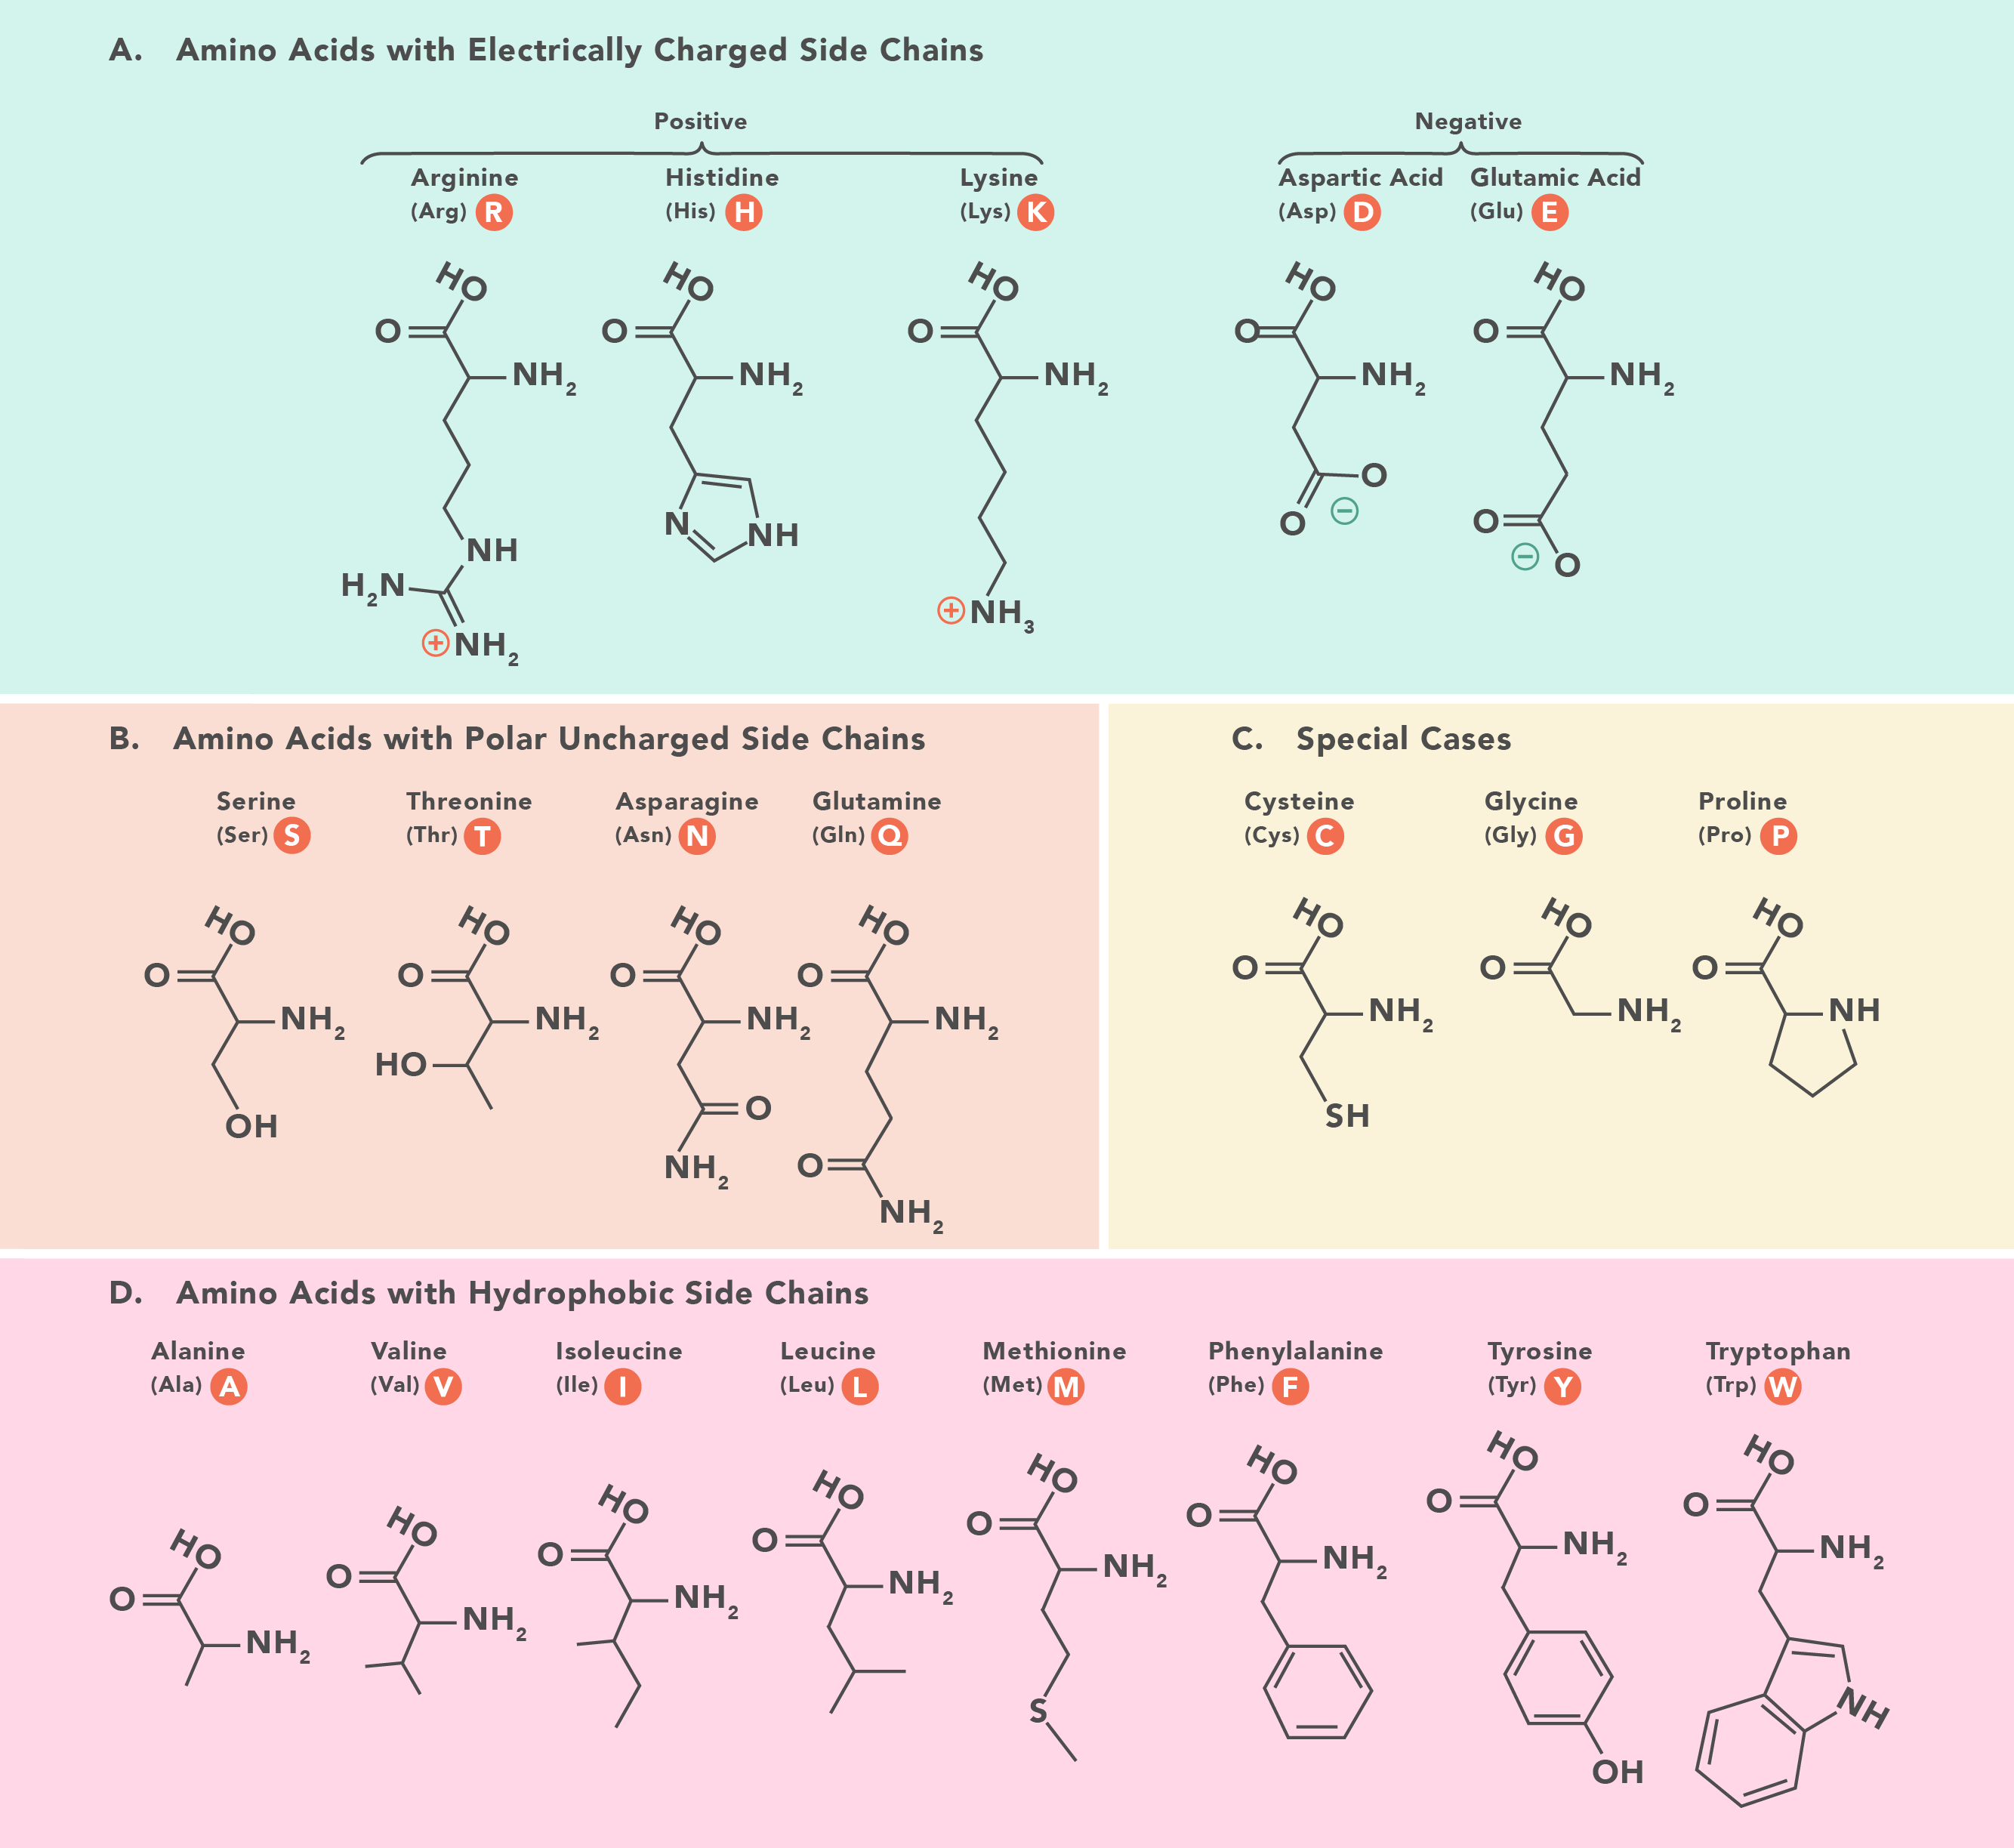

A. Amino acids with electric charges (more likely to interact with water):
    - R, H, K, D, E
B. Amino acids with Polar, uncharged, properties (will interact with water, but less attracted to it than charged amino acids):
    - S, T, N, Q
C. Special cases
    - C, G, P
D. Amino acids that are hydrophobic (won't interact with water):
    - A, V, I, L, M, F, Y, W


Note, that for solubility especially, the broken down segments above will likely be important for telling if a protein is soluble. The better an amino acid interacts with water, the more soluble it is.
- It is important to know, however, that we expect to have soluble proteins that contain a good amount of hydrophobic amino acids. This is because the proteins don't fold based on sequences, as protein folding is a much more complicated problem that goes far beyond the amino acid sequences. When protein sequences fold, they fold so the hydrophobic amino acids join in the middle, and the hydrophilic amino acids join outside.
- Another thing to acknowledge, that for proteins in the body, most are going to be soluble. Fortunately, this benchmark has given us fairly reasonable class splits, so our model should be able to see enough soluble proteins.

Next I want to look into amino acid frequencies with respect to each class label.

The reason that this is useful, is because this information could indicate that there are biochemical properties within each amino acid that are meaningful for the labels.

For example, a soluble protein may contain a lot of amino acids that are polar/hydrophillic/charged (work well with water). An insoluble protein may contain more amino acids that are nonpolar/hydrophobic/charged. Note, that proteins don't fold in a clean manner, they fold so the insoluble amino acids are bunched into the middle, making the soluble ones go to the outside. The folding process doesn't really have to do with the sequence order, it is an entirely different problem.

For localization, maybe one class has more amino acids than another. And those amino acids may have something in common.

Overall, we are looking at the distribution of amino acids in a sequence in hopes of maybe identifying some patterns there.

In [67]:
from collections import Counter

def mean_aa_counts_by_label(dfs_by_split, task_name, use_split='train'):
    if use_split == 'all':
        df = pd.concat(dfs_by_split.values(), ignore_index=True)
    else:
        df = dfs_by_split[use_split].copy()

    # Count amino acids per sequence, then average counts within each label.
    seq_counts = df['sequence'].fillna('').astype(str).str.upper().apply(
        lambda s: Counter(ch for ch in s if 'A' <= ch <= 'Z')
    )
    aa_counts_df = pd.DataFrame(seq_counts.tolist()).fillna(0)

    mean_counts = (
        aa_counts_df.groupby(df['label'])
        .mean()
        .sort_index()
    )

    # Sort amino acids by overall abundance to make the heatmap easier to read.
    aa_order = mean_counts.mean(axis=0).sort_values(ascending=False).index
    mean_counts = mean_counts.loc[:, aa_order]

    display(mean_counts.round(2))

    plt.figure(figsize=(max(10, 0.7 * len(mean_counts.columns)), max(4, 0.7 * len(mean_counts.index))))
    sns.heatmap(mean_counts, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'mean count per protein'})
    plt.title(f"{task_name.title()} ({use_split}) - Mean Amino Acid Count per Label")
    plt.xlabel('Amino acid')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()

    return mean_counts


,L,S,A,V,G,E,K,I,T,R,...,Q,Y,H,M,C,W,X,U,Z,B
label,,,,,,,,,,,,,,,,,,,,,
0,61.29,48.35,40.68,39.30,39.19,30.91,27.05,32.67,33.13,27.91,...,20.89,18.21,12.53,13.76,12.27,8.57,0.00,0.00,0.00,0.0
1,51.51,46.68,36.27,31.65,31.02,40.59,35.61,27.30,28.41,29.20,...,24.97,14.96,12.99,11.63,8.77,5.34,0.00,0.00,0.00,0.0
2,50.51,35.02,29.68,29.85,27.19,26.00,24.67,25.84,24.01,21.45,...,16.09,16.51,11.05,10.76,7.58,7.80,0.00,0.00,0.00,0.0
3,53.84,41.72,32.41,32.21,28.28,33.06,30.06,28.29,26.15,25.71,...,20.82,16.60,12.37,12.29,8.62,7.73,0.00,0.00,0.00,0.0
4,52.83,41.55,32.59,33.51,31.79,25.93,24.28,32.58,27.07,20.62,...,16.75,18.15,10.52,11.49,8.10,7.19,0.07,0.00,0.00,0.0
5,37.70,28.36,27.31,24.23,24.35,23.04,25.20,20.65,19.90,21.32,...,14.52,11.03,8.73,8.77,5.40,4.24,0.00,0.00,0.00,0.0
6,47.27,50.18,35.46,29.29,31.62,40.79,37.85,24.22,28.00,31.09,...,26.44,13.94,13.81,11.77,9.15,4.89,0.00,0.00,0.00,0.0
7,44.01,33.69,33.67,30.58,31.25,25.66,26.27,24.69,22.83,23.69,...,15.79,13.90,10.00,9.94,6.28,5.73,0.00,0.00,0.00,0.0
8,39.60,37.07,32.06,30.37,29.40,27.05,24.95,22.33,21.70,22.90,...,12.89,11.12,7.83,9.44,5.79,4.72,0.00,0.00,0.01,0.0


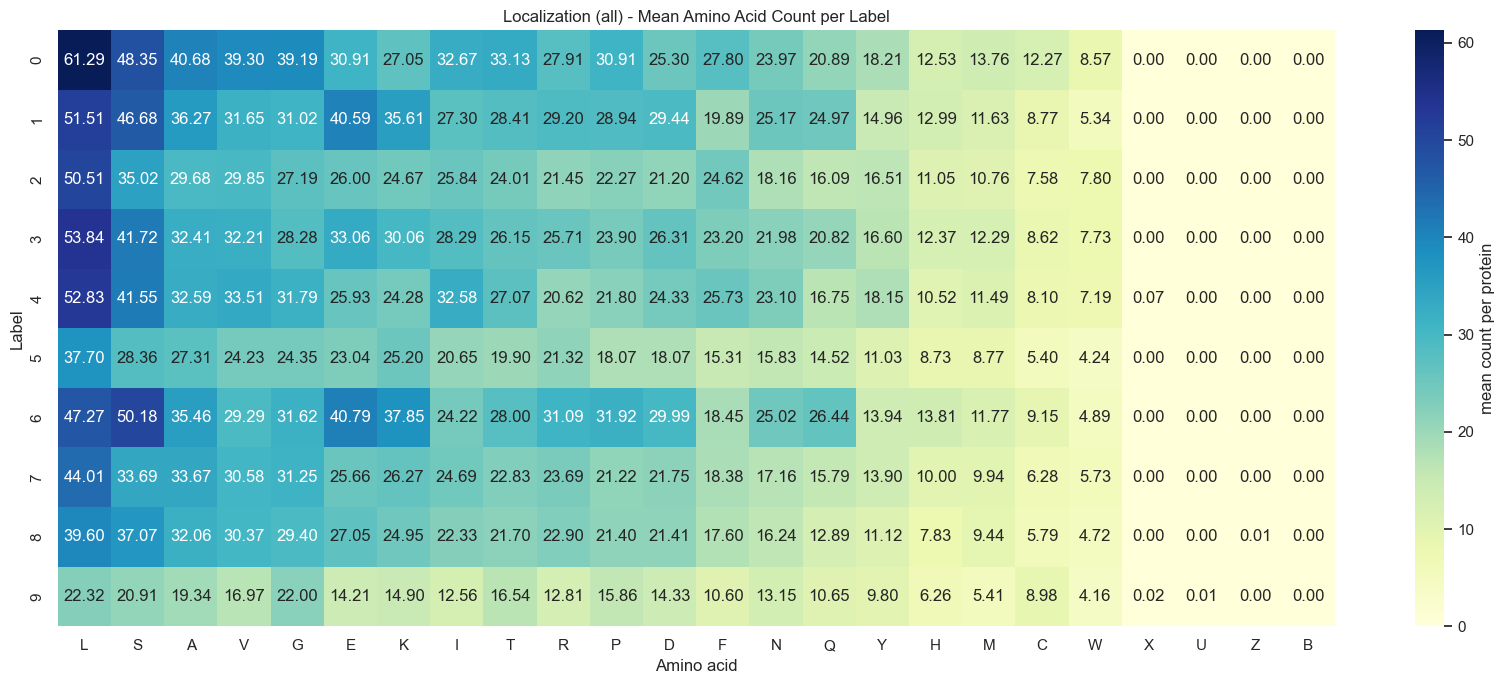

In [68]:
loc_mean_counts = mean_aa_counts_by_label(localization_dfs, 'localization', use_split='all')

Analyze above
- Seems like there is a decent amount of variance between each of the classes. Could mean that high frequency of certain amino acids could yield significant hints towards data

- B is weird, not an amino acid but found (granted very rarely) in the dataset
- X is also very weird. I presume that it represents a missing amino acid within a sequence

,L,A,E,G,V,S,K,D,I,R,T,P,N,F,Q,H,Y,M,C,W
label,,,,,,,,,,,,,,,,,,,,
0,28.73,24.41,21.11,20.30,19.77,19.45,17.61,17.62,17.94,17.39,15.74,13.52,12.56,11.83,11.92,10.26,9.99,7.70,3.95,3.48
1,27.06,23.16,21.19,20.28,19.59,18.04,17.35,16.63,16.27,15.77,14.84,13.34,11.54,11.00,10.85,9.05,9.23,6.77,3.65,3.37


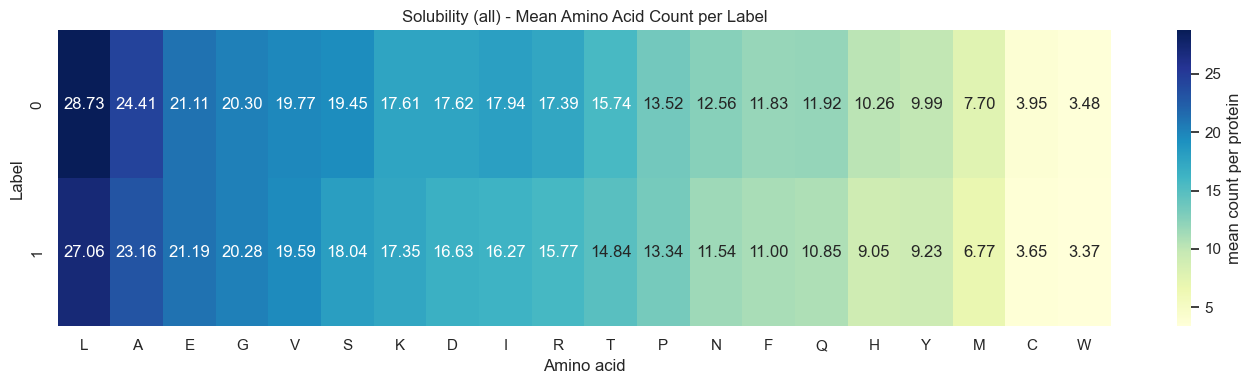

In [69]:
sol_mean_counts = mean_aa_counts_by_label(solubility_dfs, 'solubility', use_split='all')

Solubility heatmap analysis:
- Seems like the differences between the 2 classes aren't very significant

Next we want to look into the lengths of each of the sequences, and see what we are looking at there.
- What is the distribution of length for each of the sequences? Can we get a visualization of that?

In [70]:
def plot_length_distribution_heatmap(
    dfs_by_split,
    task_name,
    use_split="train",
    n_bins=20,
    normalize_within_label=True
):
    if use_split == "all":
        df = pd.concat(dfs_by_split.values(), ignore_index=True)
    else:
        df = dfs_by_split[use_split].copy()

    lengths = df["sequence"].fillna("").astype(str).str.len()
    labels = df["label"]

    # Build equally spaced length bins based on observed min/max.
    min_len, max_len = int(lengths.min()), int(lengths.max())
    if min_len == max_len:
        edges = np.array([min_len, min_len + 1], dtype=float)
    else:
        edges = np.linspace(min_len, max_len + 1, n_bins + 1)

    bin_labels = [
        f"{int(edges[i])}-{int(edges[i + 1]) - 1}"
        for i in range(len(edges) - 1)
    ]

    length_bins = pd.cut(
        lengths,
        bins=edges,
        include_lowest=True,
        right=False,
        labels=bin_labels
    )

    if normalize_within_label:
        heat = pd.crosstab(labels, length_bins, normalize="index") * 100
        cbar_label = "% within label"
        fmt = ".1f"
    else:
        heat = pd.crosstab(labels, length_bins)
        cbar_label = "count"
        fmt = "g"

    # Remove empty bins so the heatmap is easier to read.
    heat = heat.loc[:, heat.sum(axis=0) > 0].sort_index()

    plt.figure(figsize=(max(12, 0.6 * heat.shape[1]), max(4, 0.8 * heat.shape[0])))
    sns.heatmap(
        heat,
        cmap="mako",
        annot=True,
        fmt=fmt,
        cbar_kws={"label": cbar_label}
    )
    plt.title(f"{task_name.title()} ({use_split}) - Sequence Length Distribution by Label")
    plt.xlabel("Sequence length bin")
    plt.ylabel("Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return heat


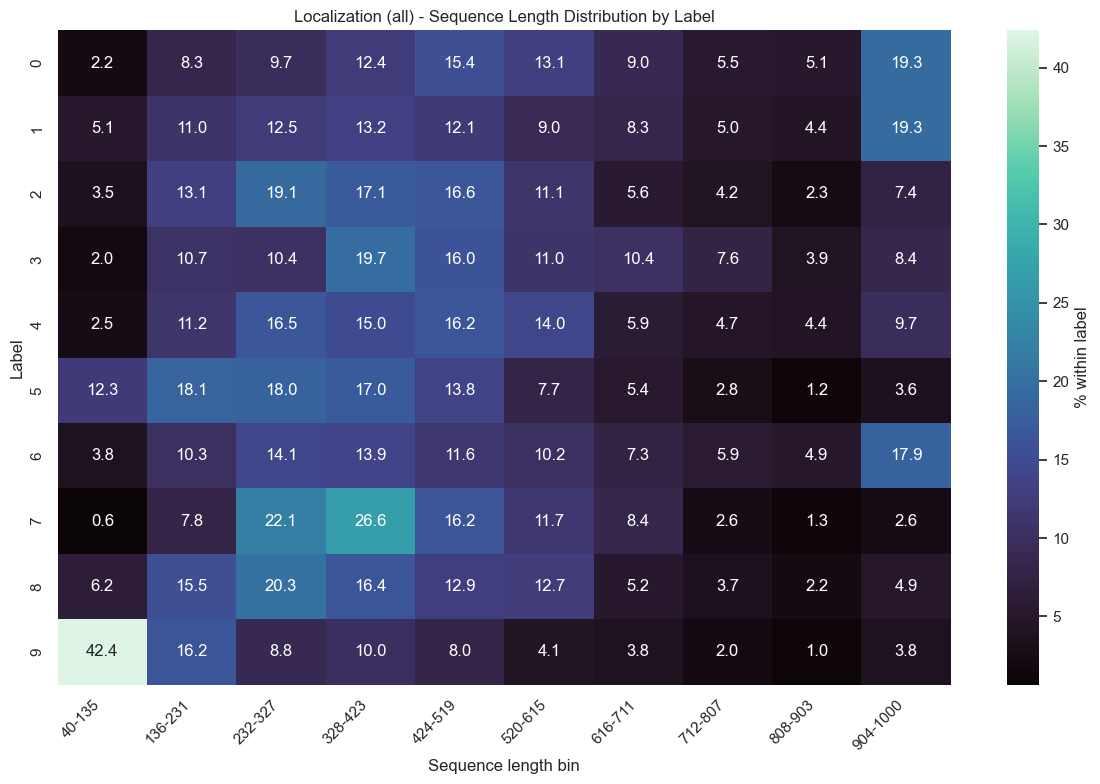

In [71]:
loc_len_heat = plot_length_distribution_heatmap(localization_dfs, "localization", use_split="all", n_bins=10)

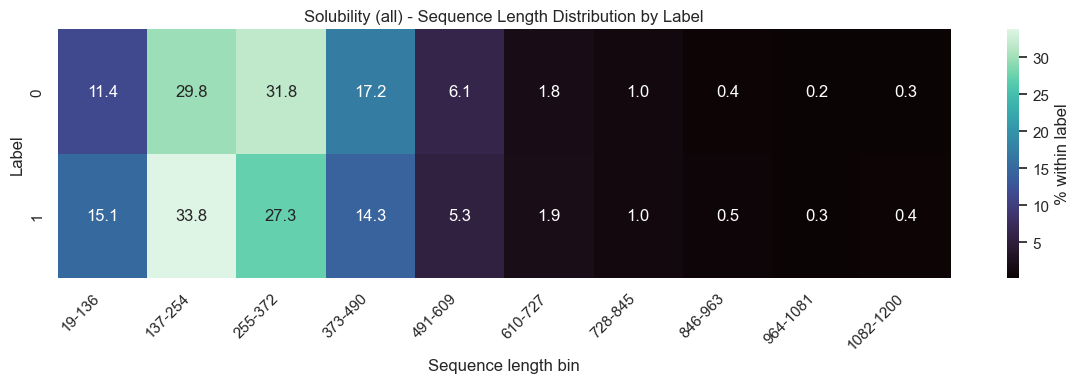

In [72]:
sol_len_heat = plot_length_distribution_heatmap(solubility_dfs, "solubility", use_split="all", n_bins=10)

In [73]:
def plot_overall_length_distribution(
    dfs_by_split,
    task_name,
    use_split="train",
    n_bins=30,
    density=False,
    color="#2E86AB",
):
    """Plot sequence-length distribution aggregated across all labels."""
    if use_split == "all":
        df = pd.concat(dfs_by_split.values(), ignore_index=True)
    else:
        df = dfs_by_split[use_split].copy()

    lengths = df["sequence"].fillna("").astype(str).str.len()

    counts, edges = np.histogram(lengths, bins=n_bins)
    widths = np.diff(edges)
    centers = edges[:-1] + widths / 2

    if density:
        values = counts / counts.sum()
        y_label = "Proportion of sequences"
    else:
        values = counts
        y_label = "Number of sequences"

    plt.figure(figsize=(12, 5))
    plt.bar(
        centers,
        values,
        width=widths * 0.95,
        color=color,
        edgecolor="#1f1f1f",
        linewidth=0.4,
        alpha=0.9,
    )
    plt.title(f"{task_name.title()} ({use_split}) - Overall Sequence Length Distribution")
    plt.xlabel("Sequence length")
    plt.ylabel(y_label)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"{task_name.title()} ({use_split}) -> n={len(lengths)}, "
        f"mean={lengths.mean():.1f}, median={lengths.median():.1f}, "
        f"min={lengths.min()}, max={lengths.max()}"
    )


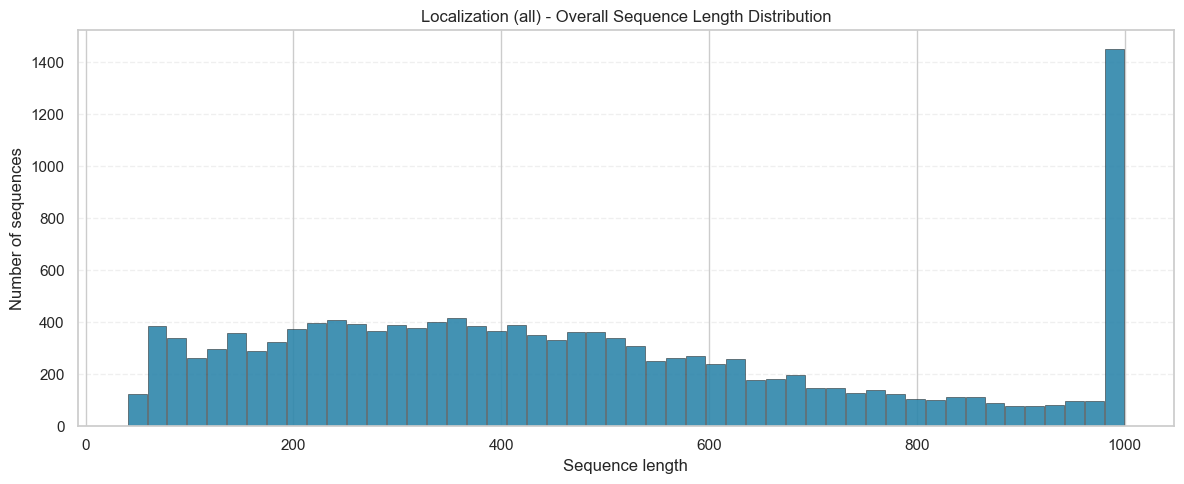

Localization (all) -> n=14004, mean=472.4, median=421.0, min=40, max=1000


In [74]:
plot_overall_length_distribution(localization_dfs, "localization", use_split="all", n_bins=50)

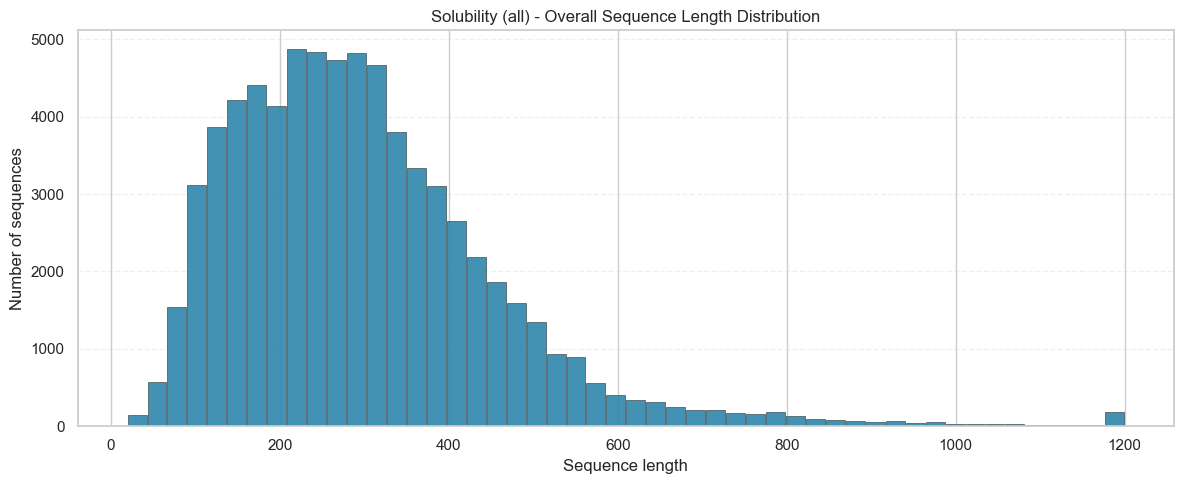

Solubility (all) -> n=71419, mean=298.4, median=275.0, min=19, max=1200


In [75]:
plot_overall_length_distribution(solubility_dfs, "solubility", use_split="all", n_bins=50)

Above are the sequence length distributions. This could be useful information for later.

My specific thoughts on this, are that augmentations may have different effects on different lengths. That meaning, the sequences that we decide to augment must be distributed uniformally among sequences of different lengths.

## Next things to investigate:
- Look into the ambiguous amino acids (B, Z, X, U, O, J)
    - Some models will be able to handle this
- Biochemical features for the proteins -> can we add information on polarity, hydrophilic/phobic, charge
- Postition dependent -> plot n-term c-term composition heatmaps
- Length-conditioned label behavior

Next viz: checks for data leakage

k-mer analysis

- check for common k-mers in the sequences (k = 3, 4)

In [89]:
localization_dfs['train'].head()

,sequence,label
0,MEFRGSGATAVEQHLLQSETPGKNGLQATSSDQVGRTLRWFTTVVL...,0
1,MKNSTAASSRWTKSRLSHFFPSYTNSSGMGAASTDQSSTQGEELHH...,0
2,MKMASSLAFLLLNFHVSLLLVQLLTPCSAQFSVLGPSGPILAMVGE...,0
3,MDHSAEKAAANAEVPQELLEEMLWYFRAEDAAPWNYSILVLAVLVV...,0
4,MIPCRAVLTFARCLIRRKIVTLDSLEDSKLCRCLTTVDLIALGVGS...,0


for each sequence:
    k-mers list = get_kmers
    

In [165]:
from collections import Counter

def get_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]


def get_kmer_counts(k, task='localization', split="train"):
    """_summary_

    Parameters
    ----------
    k : int
        Number of amino acids in a k-mer
    task : str, optional
        Solubility or localization, by default 'localization'
    split : str, optional
        train, val, test, by default "train"

    Returns
    -------
    _type_
        _description_
    """
    all_kmers = []
    
    
    if task == 'solubility':
        sequences = localization_dfs[split]
    else:
        sequences = solubility_dfs[split]
        

    for seq in sequences.sequence:
        all_kmers.extend(get_kmers(seq, k=k))

    kmer_counts = Counter(all_kmers)
    # kmer_counts.most_common(20)

    return pd.DataFrame(
        kmer_counts.items(),
        columns=["kmer", "count"]
    ).sort_values("count", ascending=False)
    
def normalize_kmer_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize k-mer counts into frequencies within each class.
    """

    normalized_df = df.copy()

    for col in normalized_df.columns:
        normalized_df[col] = (
            normalized_df[col] / normalized_df[col].sum()
        )

    return normalized_df

def kmers_by_class(k: int, task: str, split='train'):
    """_summary_

    Parameters
    ----------
    k : int
        _description_
    task : str
        _description_
    split : str, optional
        _description_, by default 'train'

    Returns
    -------
    _type_
        _description_
    """
    if task == 'localization':
        df = localization_dfs[split]
    else:
        df = solubility_dfs[split]
    
    class_kmer_counts = {}
    for label in df["label"].unique():
        subset = df[df["label"] == label]
        kmers = []
        for seq in subset["sequence"]:
            kmers.extend(get_kmers(seq, k=k))
        class_kmer_counts[label] = Counter(kmers)
    return normalize_kmer_counts(pd.DataFrame(class_kmer_counts).fillna(0))

def plot_kmers_by_class_heatmap(df: pd.DataFrame):
    # Get top k-mers overall across all classes
    top_kmers = (
        df.sum(axis=1)
        .sort_values(ascending=False)
        .index
    )

    # Subset dataframe
    plot_df = df.loc[top_kmers]
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        plot_df,
        cmap="viridis",
        annot=False
    )
    plt.title(f"{len(df.index[0])}-mer Frequencies by Class")
    plt.xlabel("Class")
    plt.ylabel(f"{len(df.index[0])}-mer")
    plt.tight_layout()
    plt.show()


def plot_kmers(kmer_df, head=20):
    """_summary_

    Parameters
    ----------
    kmer_df : pd.DataFrame
        DataFrame of kmers to plot
    """
    top_kmers = kmer_df.head(head)

    plt.figure(figsize=(12,6))
    plt.bar(top_kmers["kmer"], top_kmers["count"])
    plt.xticks(rotation=45)
    plt.title(f"Top {head} {len(kmer_df['kmer'][0])}-mers")
    plt.xlabel(f"{(kmer_df.index[0])}-mer")
    plt.ylabel("Frequency")
    plt.show()


In [166]:
localization_kmer_2_df = get_kmer_counts(k=2, task='localization')
localization_kmer_3_df = get_kmer_counts(k=3, task='localization')
localization_kmer_4_df = get_kmer_counts(k=4, task='localization')

solubility_kmer_2_df = get_kmer_counts(k=2,task='solubility')
solubility_kmer_3_df = get_kmer_counts(k=3,task='solubility')
solubility_kmer_4_df = get_kmer_counts(k=4,task='solubility')

localization_kmer_2_class_count = kmers_by_class(k=2, task='localization')
localization_kmer_3_class_count = kmers_by_class(k=3, task='localization')
localization_kmer_4_class_count = kmers_by_class(k=4, task='localization')

solubility_kmer_2_class_count = kmers_by_class(k=2, task='solubility')
solubility_kmer_3_class_count = kmers_by_class(k=3, task='solubility')
solubility_kmer_4_class_count = kmers_by_class(k=4, task='solubility')



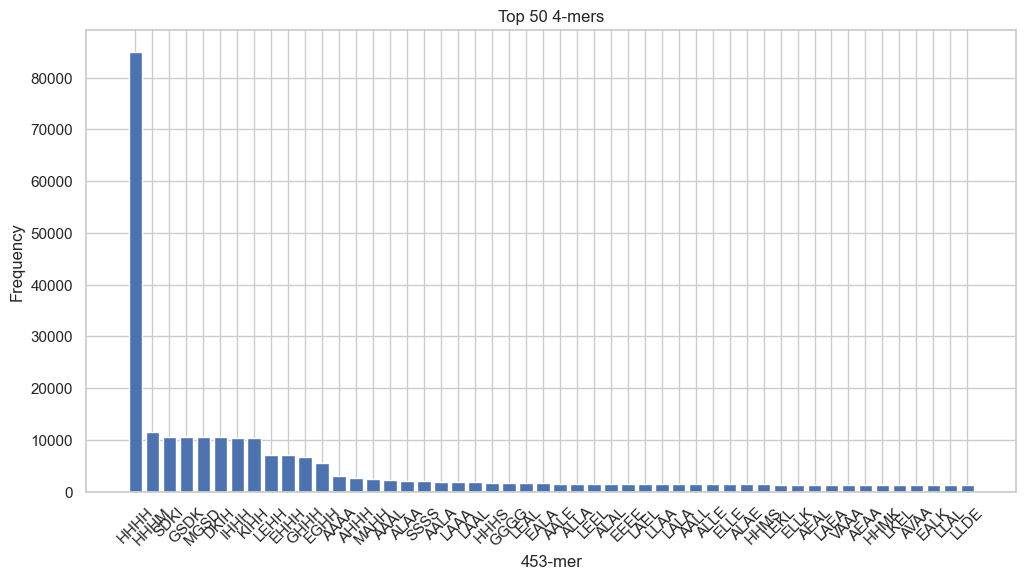

In [167]:
plot_kmers(localization_kmer_4_df, head=50)

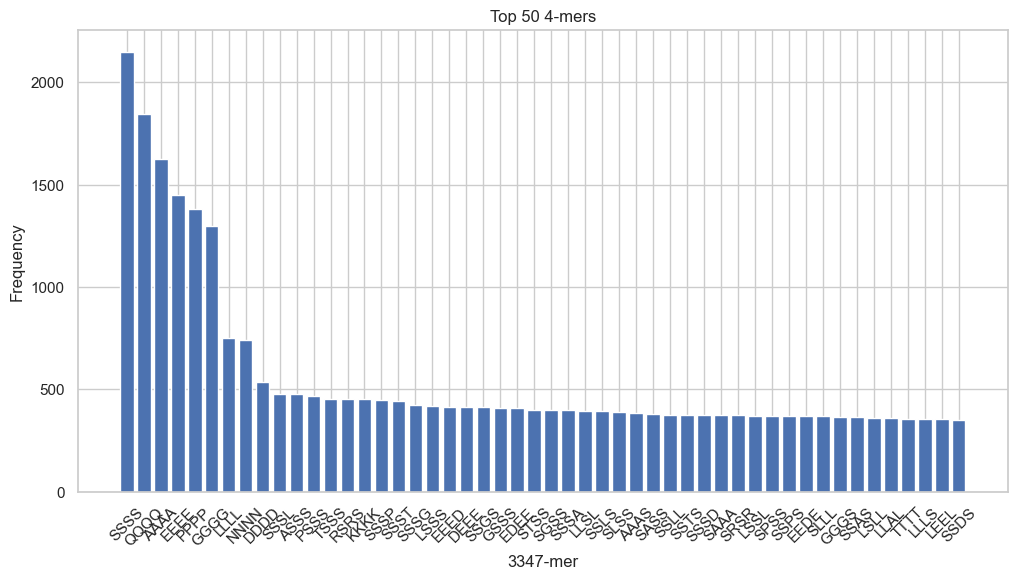

In [168]:
plot_kmers(solubility_kmer_4_df, head=50)

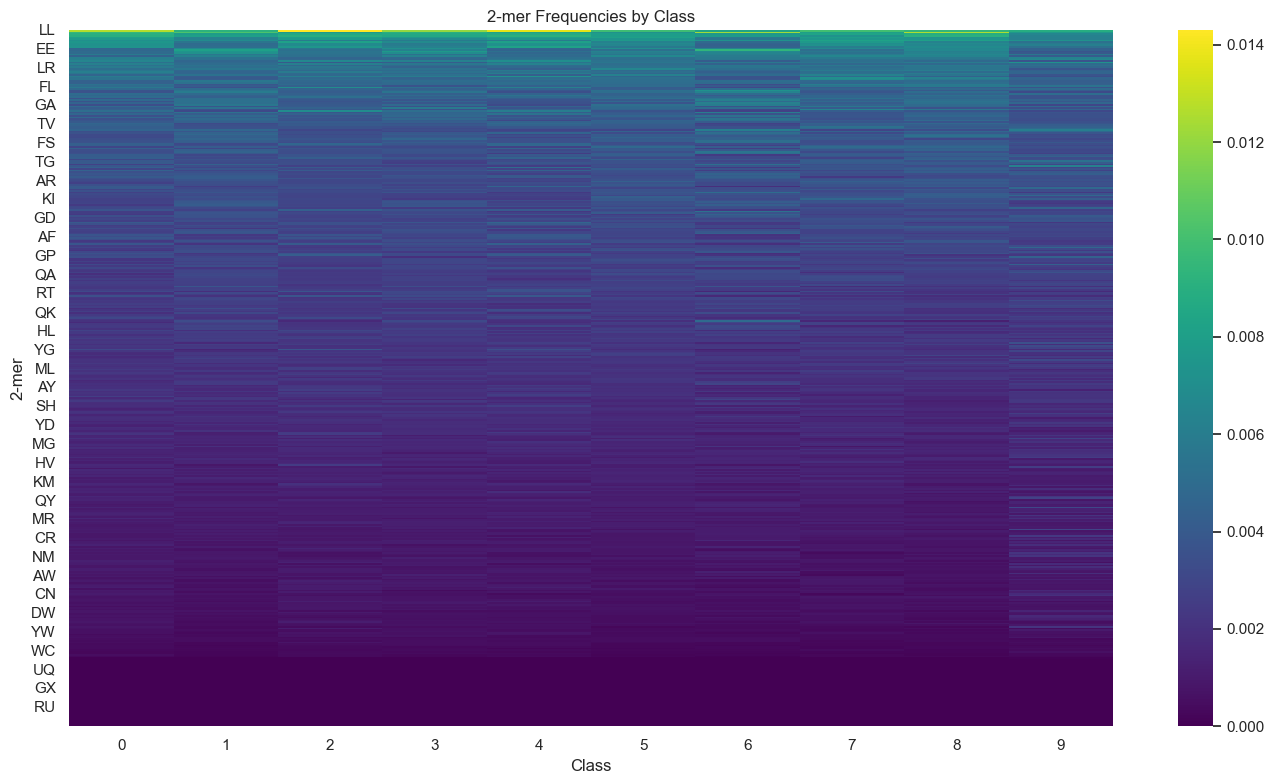

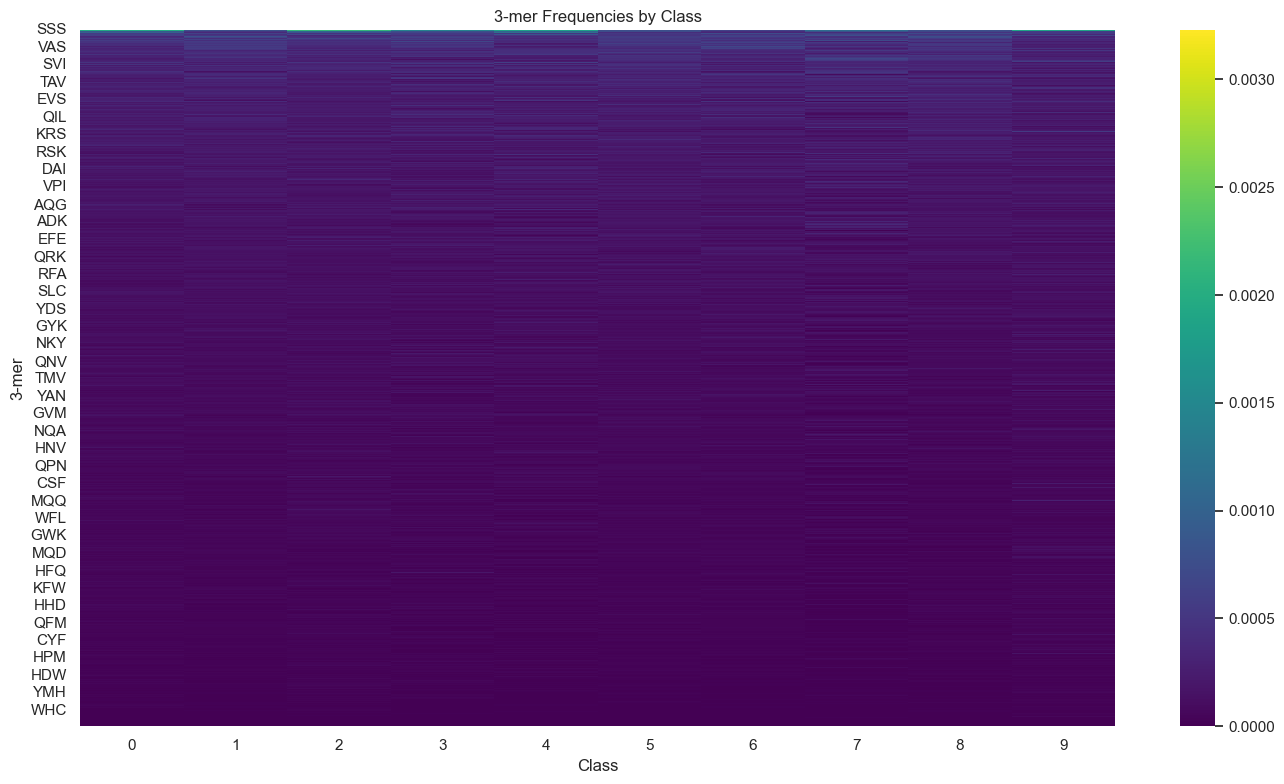

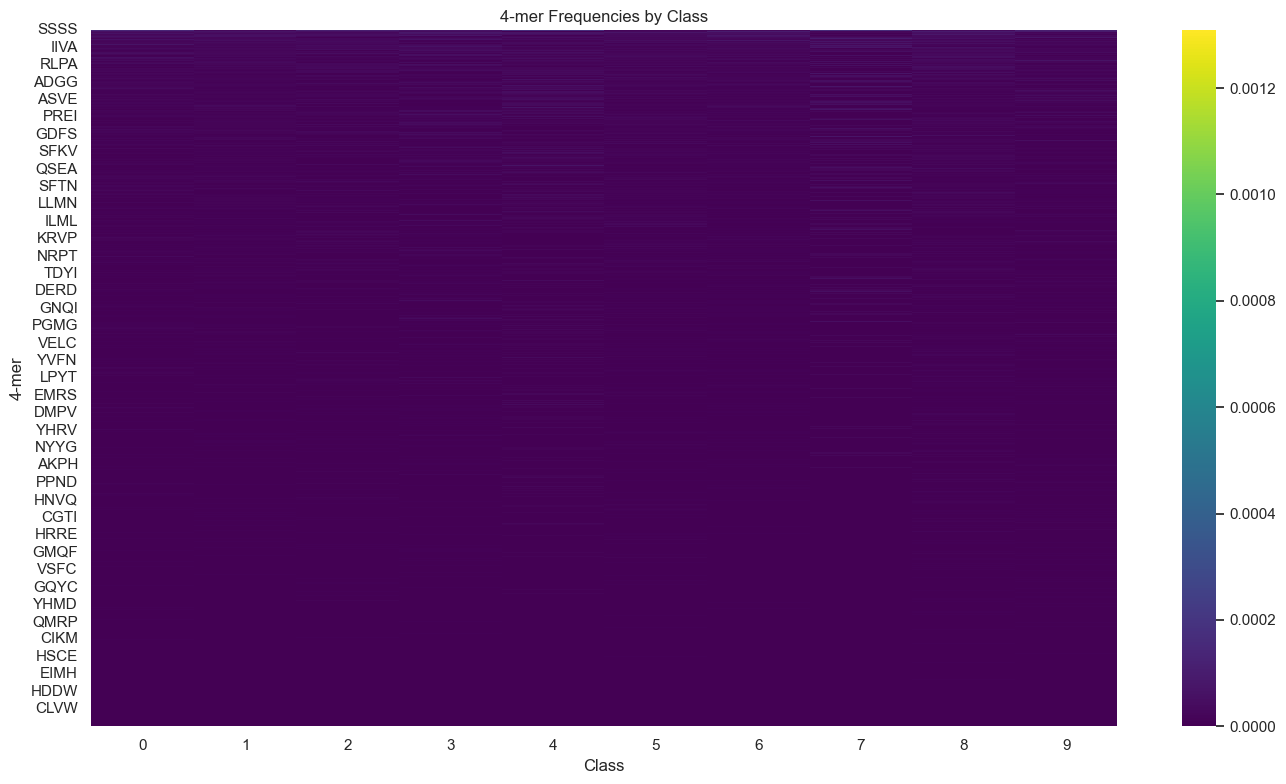

In [169]:
plot_kmers_by_class_heatmap(localization_kmer_2_class_count)
plot_kmers_by_class_heatmap(localization_kmer_3_class_count)
plot_kmers_by_class_heatmap(localization_kmer_4_class_count)

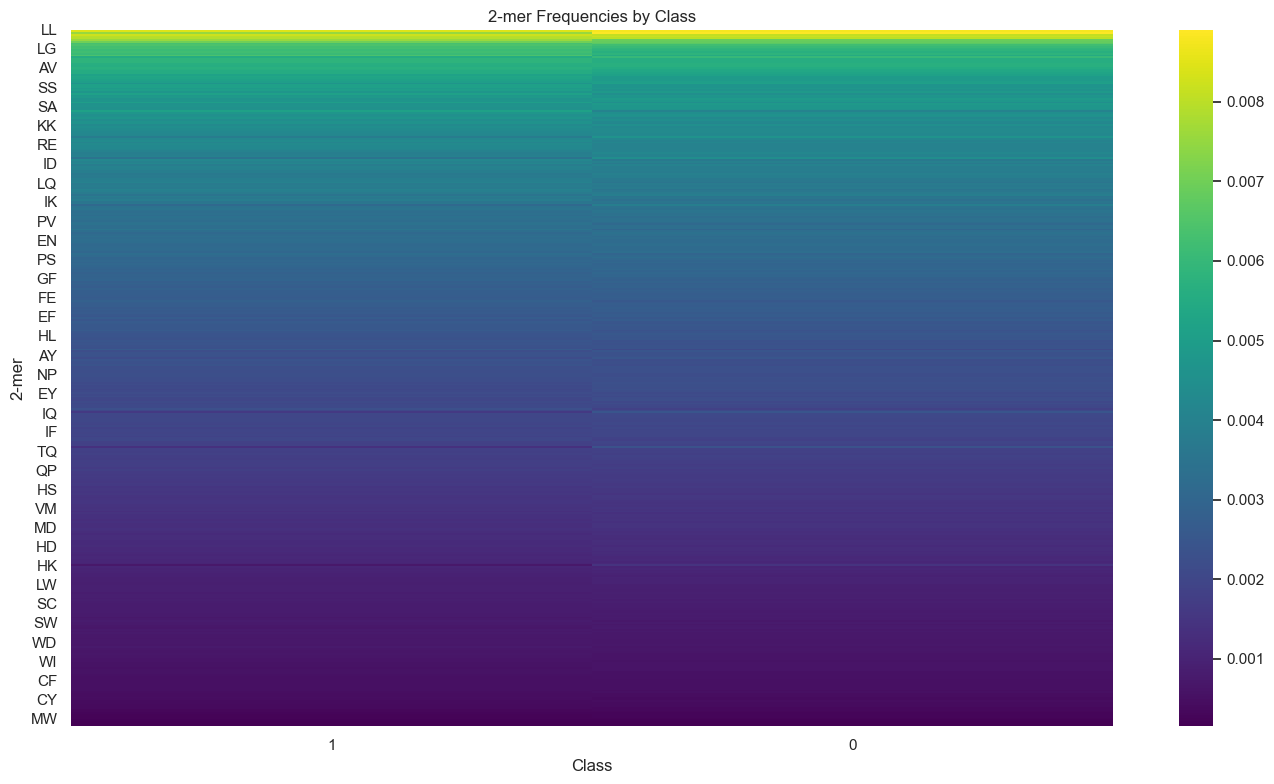

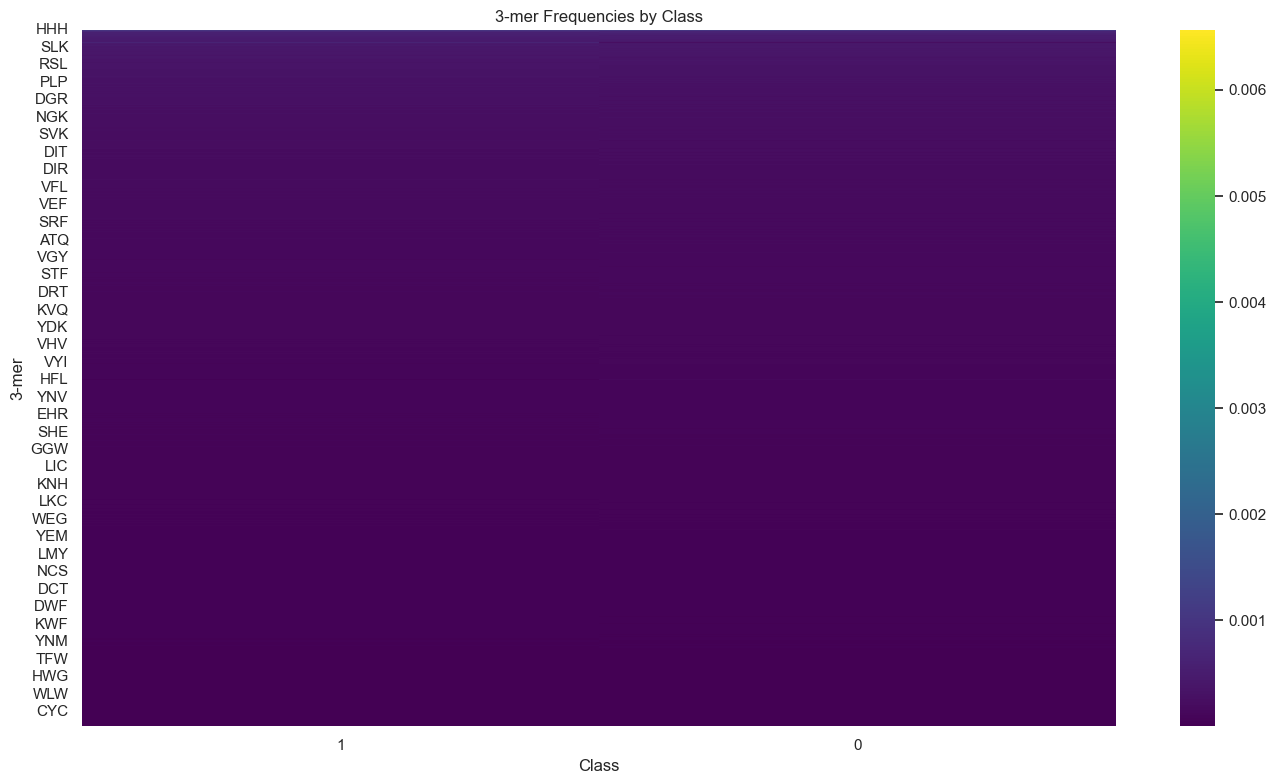

In [171]:
plot_kmers_by_class_heatmap(solubility_kmer_2_class_count)
plot_kmers_by_class_heatmap(solubility_kmer_3_class_count)
# plot_kmers_by_class_heatmap(solubility_kmer_4_class_count)


Findings here:
- 2-mer are clearly important
- 3 and 4 -mers are likely too sparse for distinguishing between the classes
- Since 2-mers (amino acid pairs) are seemingly the best distinguishers, augmentations could cause some more harmful problems

In [172]:
import numpy as np

def compute_kmer_enrichment(
    normalized_df: pd.DataFrame,
    class_a=0,
    class_b=1,
    epsilon=1e-10
):
    """
    Compute log2 enrichment between two classes.

    Positive values:
        enriched in class_b

    Negative values:
        enriched in class_a
    """

    enrichment = np.log2(
        (normalized_df[class_b] + epsilon) /
        (normalized_df[class_a] + epsilon)
    )

    enrichment_df = pd.DataFrame({
        "kmer": normalized_df.index,
        "log2_enrichment": enrichment
    })

    enrichment_df = enrichment_df.sort_values(
        "log2_enrichment",
        ascending=False
    )

    return enrichment_df

def plot_top_enriched_kmers(
    enrichment_df: pd.DataFrame,
    top_n=20
):

    top_positive = enrichment_df.head(top_n)
    top_negative = enrichment_df.tail(top_n)

    plot_df = pd.concat([top_negative, top_positive])

    plt.figure(figsize=(12, 8))

    plt.barh(
        plot_df["kmer"],
        plot_df["log2_enrichment"]
    )

    plt.axvline(0, linestyle="--")

    plt.xlabel("log2 enrichment")
    plt.ylabel("k-mer")
    plt.title("Most Enriched k-mers by Class")

    plt.tight_layout()
    plt.show()

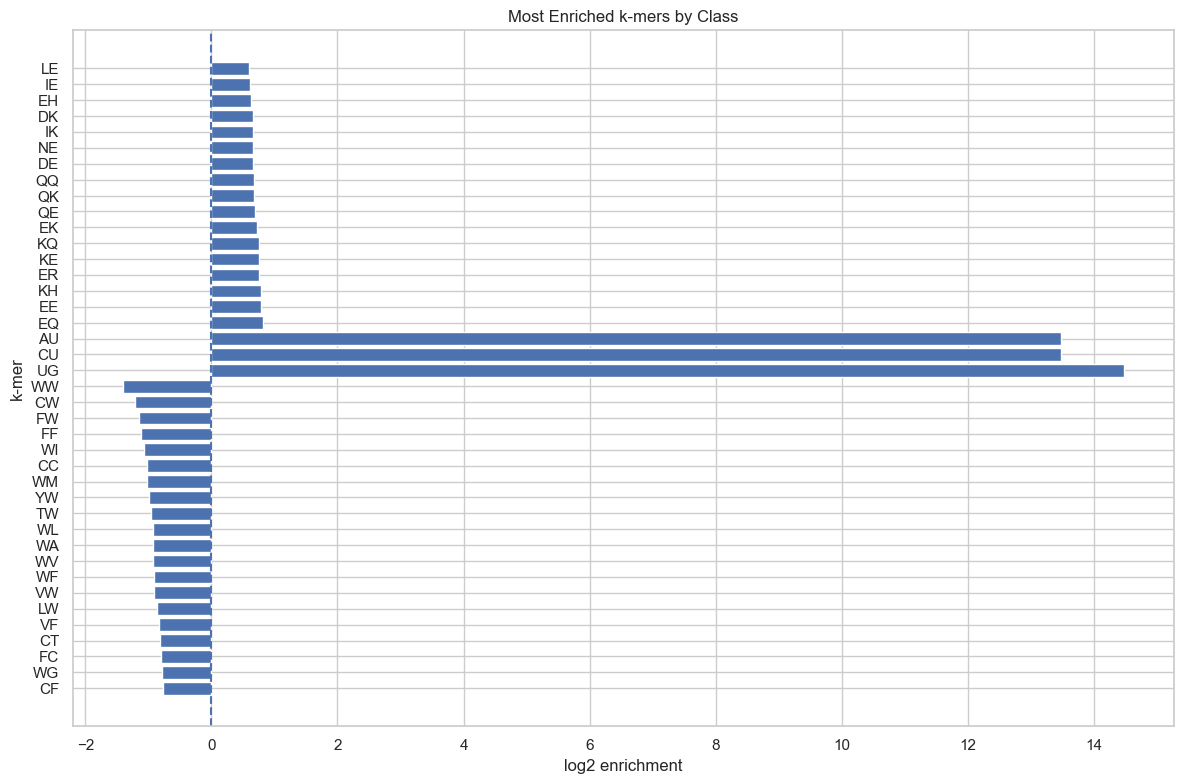

In [173]:
enrichment_localization_kmer_2_df = compute_kmer_enrichment(localization_kmer_2_class_count)
plot_top_enriched_kmers(enrichment_localization_kmer_2_df)

Above is the enrichment k-mers for the localization task. This may or may not be especially informative

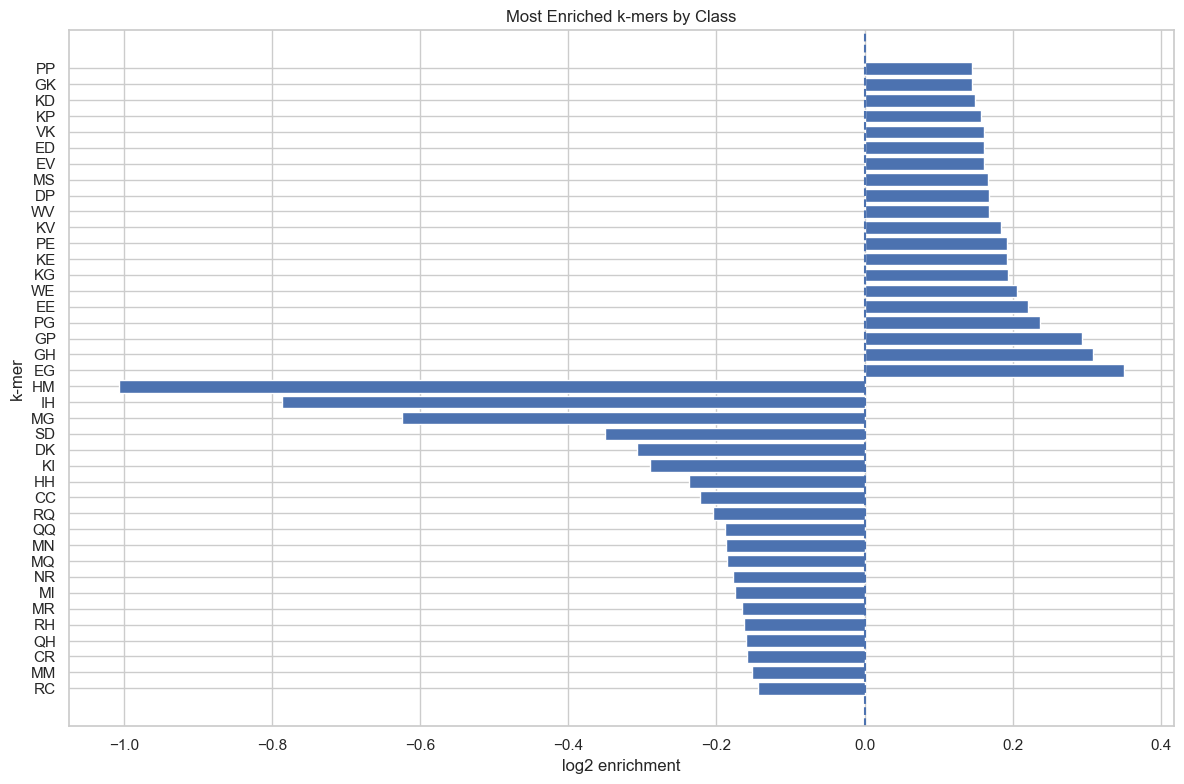

In [174]:
enrichment_solubility_kmer_2_df = compute_kmer_enrichment(solubility_kmer_2_class_count)
plot_top_enriched_kmers(enrichment_solubility_kmer_2_df)

Insoluble 2-mers are on the negative side, more soluble 2-mers are on the more positive side. This one seems to be more informative.

It might indicate that for this task, augmentations are more sensitive.